<a href="https://colab.research.google.com/github/adas754/computer_vision/blob/main/MNSIT_for_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN ON MNSIT DATASET

## MNIST is a dataset of handwritten digits (0–9) used for training and testing image classification models—especially CNNs.

In [49]:
# importing the libraries

import tensorflow as tf
# TensorFlow is the main deep-learning library; it helps build and train neural networks.

import numpy as np
# NumPy is used to work with arrays and numerical data.

from tensorflow.keras.datasets import mnist
# Imports the MNIST handwritten-digit dataset.

from tensorflow.keras.utils import to_categorical
# Converts class labels into One-Hot Encoding (OHE).

from tensorflow.keras.models import Sequential
# Sequential allows us to build the model layer-by-layer in order.

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
# Conv2D → detects features in images.
# MaxPooling2D → reduces image size.
# Flatten → converts 2D feature maps into 1D.
# Dense → fully connected neural-network layer.

import matplotlib.pyplot as plt
# Used to display and visualize images and graphs.

In [50]:
# Load the MNIST Dataset
mnist_data = mnist.load_data()

In [51]:
print(mnist_data)

((array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ...

In [52]:
# Load MNIST from Keras (gives train & test)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [53]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [54]:
y_test.shape

(10000,)

In [55]:
# 2. Combine into a single dataset variable

all_images = np.concatenate((x_train, x_test), axis=0)
# Combines training images (x_train) and testing images (x_test) into one dataset.
# axis=0 means we add the images one after another.

all_labels = np.concatenate((y_train, y_test), axis=0)
# Combines the training labels (y_train) and testing labels (y_test) into one set of labels.

In [56]:
# 3. Print dataset details
print("Total images loaded:", all_images.shape)     # (70000, 28, 28)
print("Total labels loaded:", all_labels.shape)     # (70000,)

Total images loaded: (70000, 28, 28)
Total labels loaded: (70000,)


In [57]:
# 4. Check one image matrix

print("\nMatrix of first image:\n")
# Prints the text "Matrix of first image" with blank lines for readability.

print(all_images[1])
# Prints the pixel values (matrix) of the second image.
# [1] means index 1, because Python indexing starts from 0.


Matrix of first image:

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  51 159 253
  159  50   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  48 238 252 252
  252 237   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  54 227 253 252 239
  233 252  57   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  10  60 224 252 253 252 202
   84 252 253 122   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  

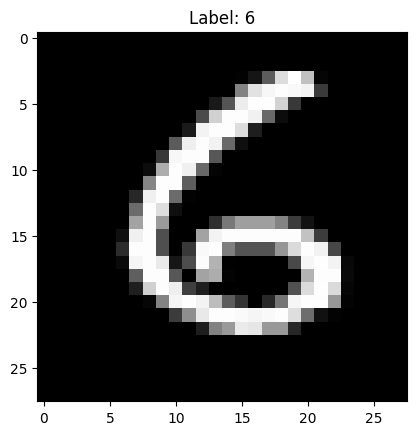

In [58]:
# 5. Show the image visually
plt.imshow(all_images[9144], cmap="gray")  # Displays the 9145th image in grayscale

plt.title("Label: " + str(all_labels[9144]))  # Displays its label as the title

plt.show()  # Shows the image

In [60]:
# 1. Normalize pixel values: 0–255 → 0–1
all_images = all_images.astype("float32") / 255.0

In [61]:
# 2. Reshape images to CNN format (N, 28, 28, 1)

all_images = np.expand_dims(all_images, axis=-1)
# Adds 1 extra dimension for the grayscale channel.
# Before: (70000, 28, 28)
# After:  (70000, 28, 28, 1)

print("After reshaping:", all_images.shape)
# Prints the new shape: (70000, 28, 28, 1)

After reshaping: (70000, 28, 28, 1)


In [62]:
print(all_images[3])

[[[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]]

 [[0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0.        ]
  [0. 

In [63]:
all_labels

array([5, 0, 4, ..., 4, 5, 6], dtype=uint8)

In [64]:
# 3. Convert labels to one-hot encoding

all_labels = to_categorical(all_labels, num_classes=10)
# Converts each digit label (0–9) into a one-hot vector of 10 values.


print("After one-hot:", all_labels.shape)
# Prints the shape of the converted labels: (70000, 10)

After one-hot: (70000, 10)


In [65]:
indices = np.arange(all_images.shape[0])
# Creates numbers from 0 to 69999, representing the index of each image.

np.random.shuffle(indices)
# Randomly shuffles those indices so the images can be selected in a random order.

In [66]:
indices

array([58363, 46436, 59556, ..., 39206, 11274, 17033])

In [45]:
all_images = all_images[indices]
# Rearranges the images according to the shuffled indices.

all_labels = all_labels[indices]
# Rearranges the labels in the same order as the images.


It **randomly shuffles the images and their labels together**, so each image still has the correct label.


In [67]:
all_labels

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [69]:
# Manual Train–Test Split for MNIST

train_size = 60000
# Sets the training dataset size to 60,000 images.

x_train = all_images[:train_size]
# Takes the first 60,000 images for training.

y_train = all_labels[:train_size]
# Takes the corresponding 60,000 labels for training.

In [71]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [73]:
x_test = all_images[train_size:]
# Takes all remaining images after the first 60,000 as test images.


y_test = all_labels[train_size:]
# Takes the corresponding labels for those 10,000 test images.

In [74]:
print("Test images:", x_train.shape)

Test images: (60000, 28, 28, 1)


In [75]:
# ---------------------------------------------------------
# Building a CNN Model for MNIST
# ---------------------------------------------------------

model = Sequential()

# 1st Convolution layer
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu',       # Detects patterns (edges, curves, shapes)
                 input_shape=(28, 28, 1)))

# 1st Pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))    #Keeps positive values only and makes CNN learn faster


# Flatten layer
model.add(Flatten()) # Converts the 2D image features into 1D

# Fully connected Dense layer
model.add(Dense(128, activation='relu')) # Learns final patterns and connects all neurons

# Output layer (10 classes → digits 0–9)
model.add(Dense(10, activation='softmax'))   #Gives probability of each digit (0–9)

# Model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [76]:
# ---------------------------------------------------------
# Compile and Train the CNN Model
# ---------------------------------------------------------

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [83]:
# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8995 - loss: 0.3387 - val_accuracy: 0.9280 - val_loss: 0.2502
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9100 - loss: 0.3053 - val_accuracy: 0.9335 - val_loss: 0.2261
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9168 - loss: 0.2782 - val_accuracy: 0.9407 - val_loss: 0.2046
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9249 - loss: 0.2505 - val_accuracy: 0.9468 - val_loss: 0.1855
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9318 - loss: 0.2271 - val_accuracy: 0.9503 - val_loss: 0.1705


In [84]:
# ---------------------------------------------------------
# Evaluate the trained model
# ---------------------------------------------------------

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9382 - loss: 0.2053
Test Loss : 0.20527030527591705
Test Accuracy : 0.9381999969482422


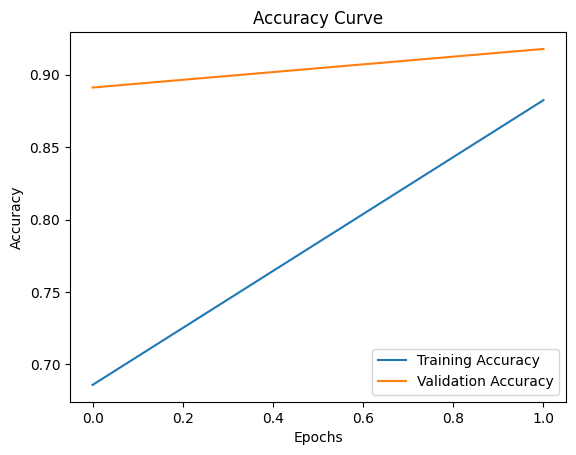

In [79]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

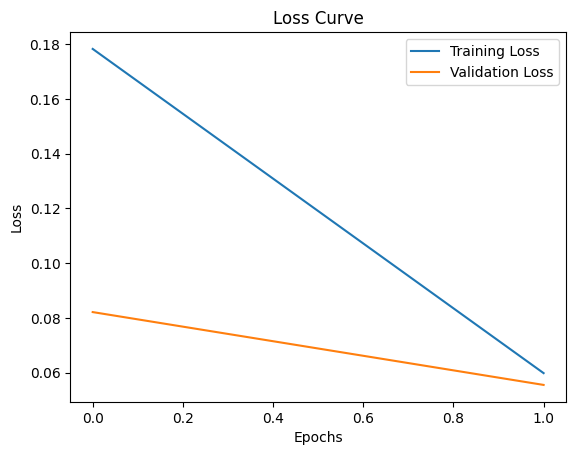

In [29]:
# Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [85]:
# Load image from your computer
import cv2
img = cv2.imread("/content/images (1).jfif", cv2.IMREAD_GRAYSCALE)

In [86]:
# Resize to 28x28
img = cv2.resize(img, (28, 28))

# Invert colors if needed (MNIST = white digit, black bg)
img = 255 - img

# Normalize 0-255 → 0-1
img = img / 255.0

# Reshape for CNN
img = img.reshape(1, 28, 28, 1)

In [87]:
prediction = model.predict(img)
predicted_digit = np.argmax(prediction)

print("Predicted Digit:", predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Digit: 3
